<a href="https://colab.research.google.com/github/durandaniel2031-jpg/prueba2/blob/main/dia_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
conexion = sqlite3.connect("torneo_smash.db")
df_original = pd.read_csv("smash_dataset_clean.csv", encoding="latin1")
df_original.to_sql("combates", conexion, if_exists="replace", index=False)
print("✅ ¡Éxito total! La base de datos relacional 'torneo_smash.db' ha sido creada y la tabla 'combates' está lista.")

✅ ¡Éxito total! La base de datos relacional 'torneo_smash.db' ha sido creada y la tabla 'combates' está lista.


In [20]:
consulta_sql = """
SELECT Personaje,Sexo,Muertes,KOs
FROM combates
ORDER BY Personaje ASC
"""
df_filtrado = pd.read_sql_query(consulta_sql, conexion)
print("📊 Datos extraídos mediante SQL con éxito:")
df_filtrado.head(24)

📊 Datos extraídos mediante SQL con éxito:


,Personaje,Sexo,Muertes,KOs
0,Bayoneta,Mujer,1.0,2.0
1,Daisy,Hombre,1.0,1.0
2,Donkey Kong,Hombre,0.0,1.0
3,Donkey Kong,Hombre,4.0,1.0
4,Game and watch,Hombre,2.0,2.0
5,Game and watch,Hombre,1.0,2.0
6,Incineroar,Hombre,2.0,1.0
7,Incineroar,Hombre,1.0,0.0
8,Inkgling,Mujer,1.0,0.0
9,Kirby,Hombre,2.0,1.0


/tmp/ipykernel_8940/1157571879.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico_barras = sns.barplot(


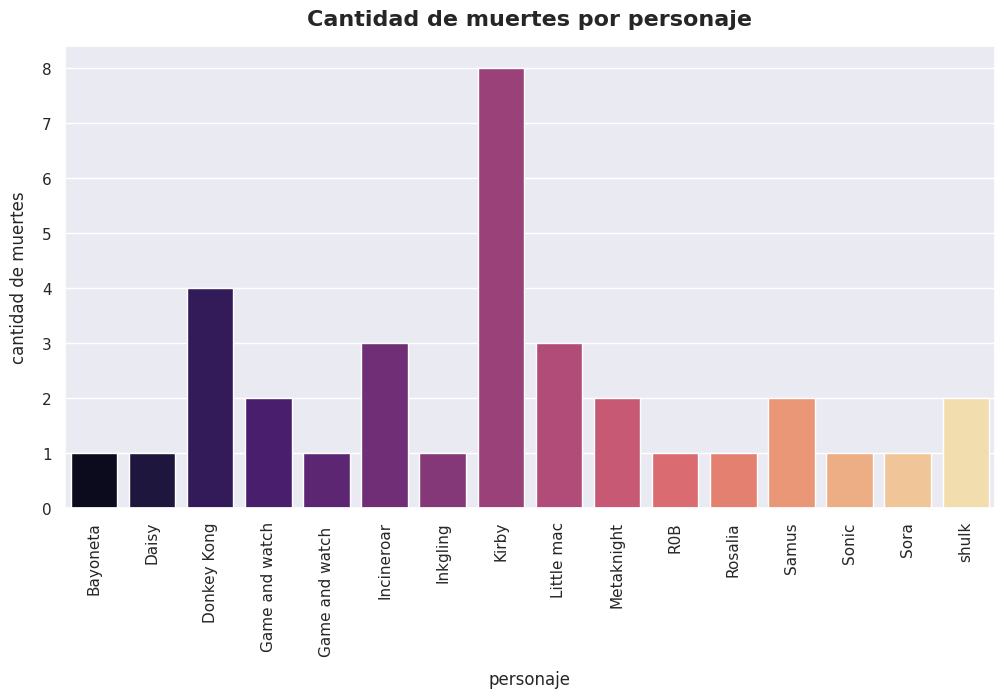

In [22]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 6))
grafico_barras = sns.barplot(
    data=df_filtrado,
    x="Personaje",
    y="Muertes",
    palette="magma",
    estimator='sum',
    errorbar=None
)
plt.title("Cantidad de muertes por personaje", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("personaje", fontsize=12, labelpad=10)
plt.ylabel("cantidad de muertes", fontsize=12, labelpad=10)
plt.xticks(rotation=90)
plt.show()